# BioCAS 2023 — Preprocessing Pipeline

Notebook de research para explorar y ejecutar la pipeline de preprocesamiento.

**Flujo:**
1. Cargar config
2. (Opcional) modificar parámetros para experimentar
3. Correr pipeline → obtener `BioCASDataset`
4. Inspeccionar resultados
5. Conectar al training loop

In [1]:
%load_ext autoreload
%autoreload 2

import sys
# sys.path.insert(0, "..")   # ajustar si el notebook está en un subdirectorio

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from pipeline_api import load_config, patch_config, show_config, run_pipeline, load_dataset, save_dataset

## 1 · Cargar configuración

In [2]:
# Config por defecto (lee config/pipeline.yaml)
cfg = load_config()
show_config(cfg)

data:
  raw_wav_dir: data/train/wav
  raw_json_dir: data/train/json
  output_dir: data/processed
  task: 1-2
stages:
  loading:
    enabled: true
  resampling:
    enabled: true
  event_extraction:
    enabled: true
  balanced_sampling:
    enabled: true
  concatenation:
    enabled: true
  padding:
    enabled: true
  augmentation:
    enabled: true
  log_mel:
    enabled: true
  spec_augment:
    enabled: true
  normalization:
    enabled: true
loading:
  target_sr: 4000
  keep_poor_quality: false
event_extraction:
  min_duration_s: 0.2
  keep_unlabelled: false
balanced_sampling:
  strategy: proportional
  target_samples_per_class: null
  random_seed: 42
concatenation:
  min_duration_s: 8.0
  max_duration_s: 8.0
padding:
  mode: reflect
  target_duration_s: 8.0
augmentation:
  spec_augment:
    enabled: true
    freq_mask_param: 27
    time_mask_param: 80
    num_freq_masks: 2
    num_time_masks: 2
    mask_value: 0.0
  time_shift:
    enabled: true
    max_shift_s: 0.5
  add_noise:


In [11]:
cfg_test = load_config(overrides=[
    "data.raw_wav_dir=data/test/wav",
    "data.raw_json_dir=data/test/json",
    "stages.balanced_sampling.enabled=false",
    "stages.augmentation.enabled=false",
    "stages.spec_augment.enabled=false",
])

## 2 · Correr la pipeline completa

In [3]:
import torch
import torchaudio

print(f"Torch version: {torch.__version__}")
print(f"Audio version: {torchaudio.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

Torch version: 2.11.0+cu126
Audio version: 2.11.0+cu126
CUDA disponible: True


In [6]:
# run_pipeline() = build + run + wrap en BioCASDataset
dataset = run_pipeline(cfg)
print(dataset)

PreprocessingPipeline
  Device      : cuda (NVIDIA GeForce RTX 3060 Ti)
  Chunk size  : 256
  Task        : 1-2
  Target SR   : 4000 Hz
  Duration    : 8.0s
  Mel bins    : 64

  Fase 1 — sin audio (CPU)
    Loading(lazy) → EventExtraction → BalancedSampling
    Sampling    : proportional

  Fase 2 — chunks con GPU
    WavLoad → Slice → Resample → Concat → Pad
    → WavAug → LogMel → SpecAugment → Norm
    Augment     : shift=True noise=True stretch=True
    SpecAugment : True
    Normalize   : instance

── Fase 1: Metadata (sin audio) ──────────────────────────


  loading:   0%|          | 0/5258 [00:00<?, ?file/s]

  Recordings: 5,028


  extracting events:   0%|          | 0/5028 [00:00<?, ?recording/s]

  Events:     19,863  (valid labels: 19,863)
  Balanced:   19,862  {'CC': 863, 'FC': 3307, 'N': 10506, 'R': 1182, 'S': 662, 'W': 2814, 'WC': 528}

── Fase 2: Procesamiento en 78 chunks de 256 ──


...

  waveform aug:   0%|          | 0/150 [00:00<?, ?sample/s]

  log-mel:   0%|          | 0/150 [00:00<?, ?sample/s]

  SpecAugment:   0%|          | 0/150 [00:00<?, ?sample/s]

  normalizing:   0%|          | 0/150 [00:00<?, ?sample/s]


── Done: 19,862 samples en 283.3s ──
BioCASDataset(n=19862, n_classes=7, feature_shape=(1, 64, 251))


In [ ]:
save_dataset(dataset, "data/processed_v3/train")

✓ Dataset guardado en 'data\processed_v3'
  features.npy : (19862, 64, 251)  dtype=float32
  labels.npy   : (19862,)
  metadata.json: 19862 entradas


In [12]:
# run_pipeline() = build + run + wrap en BioCASDataset
test_dataset = run_pipeline(cfg_test)
print(test_dataset)

PreprocessingPipeline
  Device      : cuda (NVIDIA GeForce RTX 3060 Ti)
  Chunk size  : 256
  Task        : 1-2
  Target SR   : 4000 Hz
  Duration    : 8.0s
  Mel bins    : 64

  Fase 1 — sin audio (CPU)
    Loading(lazy) → EventExtraction → BalancedSampling
    Sampling    : proportional

  Fase 2 — chunks con GPU
    WavLoad → Slice → Resample → Concat → Pad
    → WavAug → LogMel → SpecAugment → Norm
    Augment     : shift=True noise=True stretch=True
    SpecAugment : True
    Normalize   : instance

── Fase 1: Metadata (sin audio) ──────────────────────────


  loading:   0%|          | 0/1309 [00:00<?, ?file/s]

  Recordings: 1,309


  extracting events:   0%|          | 0/1309 [00:00<?, ?recording/s]

  Events:     4,706  (valid labels: 4,706)
  Balanced:   4,706  {'CC': 65, 'FC': 1885, 'N': 2175, 'R': 7, 'S': 8, 'W': 305, 'WC': 261}

── Fase 2: Procesamiento en 19 chunks de 256 ──


...

  concatenation:   0%|          | 0/98 [00:00<?, ?sample/s]

  padding:   0%|          | 0/98 [00:00<?, ?sample/s]

  log-mel:   0%|          | 0/98 [00:00<?, ?sample/s]

  normalizing:   0%|          | 0/98 [00:00<?, ?sample/s]


── Done: 4,706 samples en 17.1s ──
BioCASDataset(n=4706, n_classes=7, feature_shape=(1, 64, 251))


In [14]:
save_dataset(test_dataset, "data/processed_v3/test")

✓ Dataset guardado en 'data\processed_v3\test'
  features.npy : (4706, 64, 251)  dtype=float32
  labels.npy   : (4706,)
  metadata.json: 4706 entradas


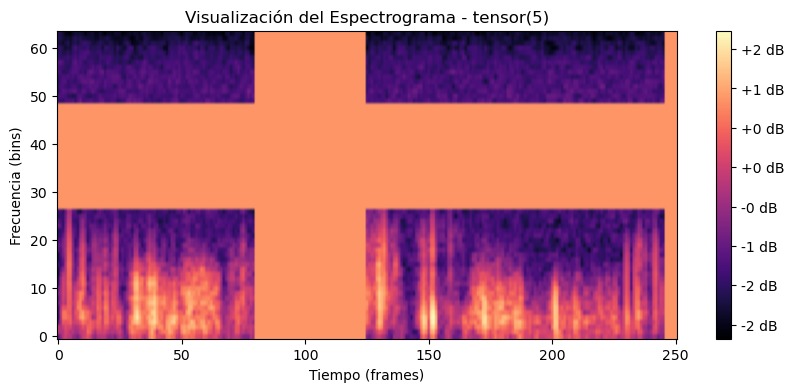

In [12]:
import matplotlib.pyplot as plt

sample, label = dataset.__getitem__(1000)


sample_np = sample.squeeze().detach().cpu().numpy()

plt.figure(figsize=(10, 4))
# origin='lower' para que las frecuencias bajas queden abajo
plt.imshow(sample_np, aspect='auto', origin='lower', cmap='magma')

plt.title('Visualización del Espectrograma - ' + str(label))
plt.xlabel('Tiempo (frames)')
plt.ylabel('Frecuencia (bins)')
plt.colorbar(format='%+2.0f dB')
plt.show()

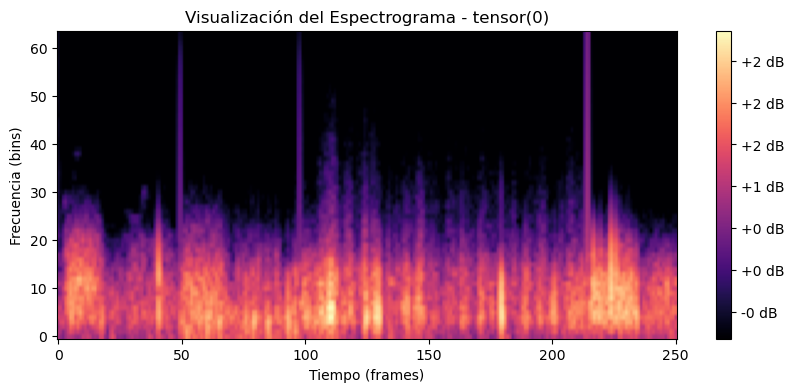

In [15]:
import matplotlib.pyplot as plt

sample, label = test_dataset.__getitem__(1000)


sample_np = sample.squeeze().detach().cpu().numpy()

plt.figure(figsize=(10, 4))
# origin='lower' para que las frecuencias bajas queden abajo
plt.imshow(sample_np, aspect='auto', origin='lower', cmap='magma')

plt.title('Visualización del Espectrograma - ' + str(label))
plt.xlabel('Tiempo (frames)')
plt.ylabel('Frecuencia (bins)')
plt.colorbar(format='%+2.0f dB')
plt.show()

## Training loop

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split

# Split train / val
n_val   = int(len(dataset) * 0.15)
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

# Inspeccionar un batch
features, labels = next(iter(train_loader))
print(f"features : {features.shape}   dtype={features.dtype}")
print(f"labels   : {labels.shape}     dtype={labels.dtype}")
print(f"Pesos para CrossEntropyLoss: {dataset.class_weights}")

In [ ]:
# Ejemplo mínimo de training loop
import torch.nn as nn

# model = Red(...)   ← arquitectura aquí
# criterion = nn.CrossEntropyLoss(weight=dataset.class_weights)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# for epoch in range(N_EPOCHS):
#     model.train()
#     for features, labels in train_loader:
#         features, labels = features.to(device), labels.to(device)
#         loss = criterion(model(features), labels)
#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()

print("Dataset listo para training.")
print(f"  Train : {len(train_ds)} muestras")
print(f"  Val   : {len(val_ds)} muestras")
print(f"  Shape : {dataset.feature_shape}  (C, n_mels, T)")
print(f"  Clases: {dataset.num_classes}")